# 04 · Visualizations

Distribution and relationship charts that round out the analysis:
how metrics are distributed, how they correlate, and what the
most-engaged content looks like.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned_social_media_sentiment.csv")
df["engagement"] = df["like_count"] + df["share_count"] + df["comment_count"]
df.head()

,platform,post_id,user_id,username,user_verified,user_followers_count,user_location,post_text,language,hashtags,...,sentiment_label,sentiment_score,emotion_label,toxicity_score,sarcasm_detected,spam_flag,data_source_url,vader_compound,vader_label,engagement
0,YouTube,YO_100000,user_2679,rxckafna,True,375410,Germany,I don’t agree with this at all.,ur,"#news,#update",...,Positive,0.82,Sad,0.10,False,True,https://www.youtube.com,0.3612,Neutral,9821
1,Reddit,RE_100001,user_3045,zjovqwps,True,346702,UK,Worst decision ever made.,fr,"#trending,#ai",...,Neutral,-0.02,Angry,0.67,True,True,https://www.reddit.com,-0.6249,Neutral,7560
2,YouTube,YO_100002,user_4598,rvufaigf,False,111487,Germany,This trend is getting out of hand.,de,"#news,#update",...,Positive,0.62,Neutral,0.43,False,False,https://www.youtube.com,0.4939,Neutral,17289
3,Twitter,TW_100003,user_3504,qukbjznz,True,356674,Germany,Pretty neutral about the update.,en,"#trending,#ai",...,Neutral,0.14,Sad,0.97,True,True,https://www.twitter.com,0.4939,Neutral,11985
4,YouTube,YO_100004,user_3646,ounaiayw,False,125551,USA,"Loved the explanation, very helpful.",es,"#trending,#ai",...,Neutral,-0.05,Fear,0.95,True,False,https://www.youtube.com,0.7902,Neutral,7070


## Sentiment and platform distribution

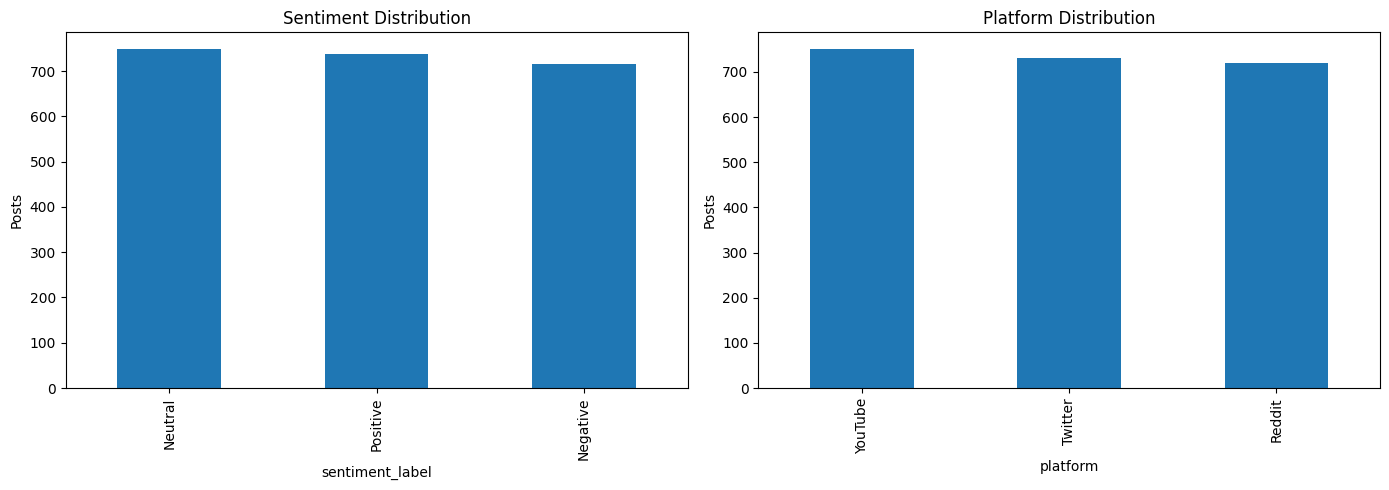

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["sentiment_label"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Sentiment Distribution")
axes[0].set_ylabel("Posts")

df["platform"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Platform Distribution")
axes[1].set_ylabel("Posts")

plt.tight_layout()
plt.show()

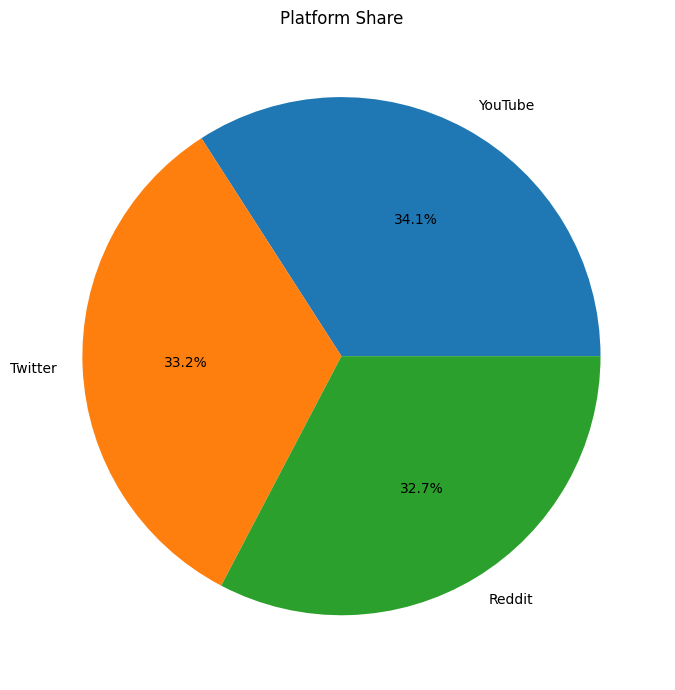

In [3]:
plt.figure(figsize=(7, 7))
df["platform"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Platform Share")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Engagement metric distributions

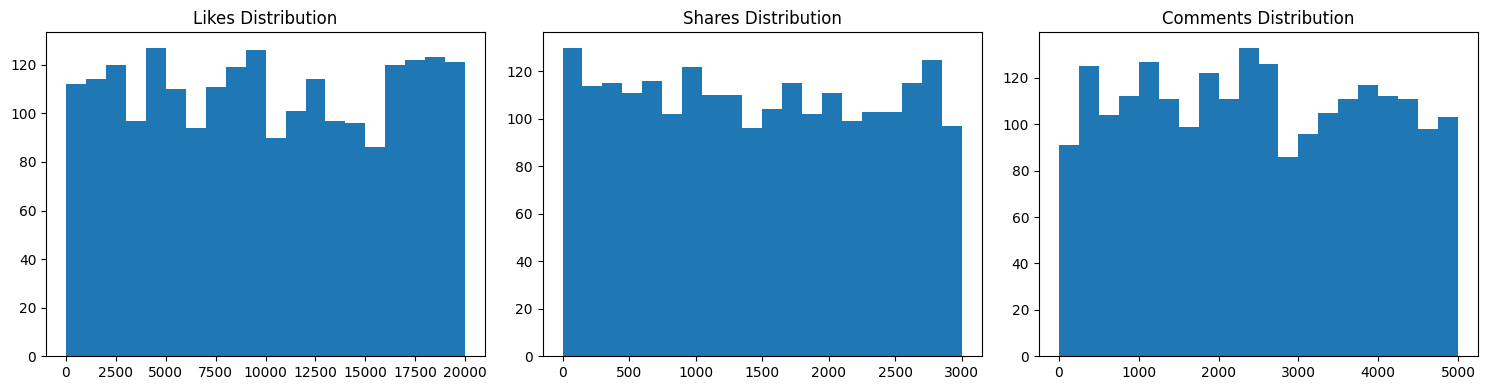

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["like_count"], bins=20)
axes[0].set_title("Likes Distribution")

axes[1].hist(df["share_count"], bins=20)
axes[1].set_title("Shares Distribution")

axes[2].hist(df["comment_count"], bins=20)
axes[2].set_title("Comments Distribution")

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

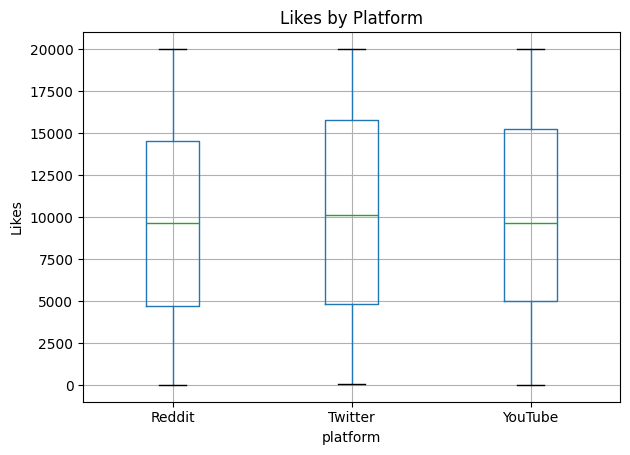

In [5]:
plt.figure(figsize=(8, 5))
df.boxplot(column="like_count", by="platform")
plt.title("Likes by Platform")
plt.suptitle("")
plt.ylabel("Likes")
plt.tight_layout()
plt.show()

## Relationships between engagement metrics

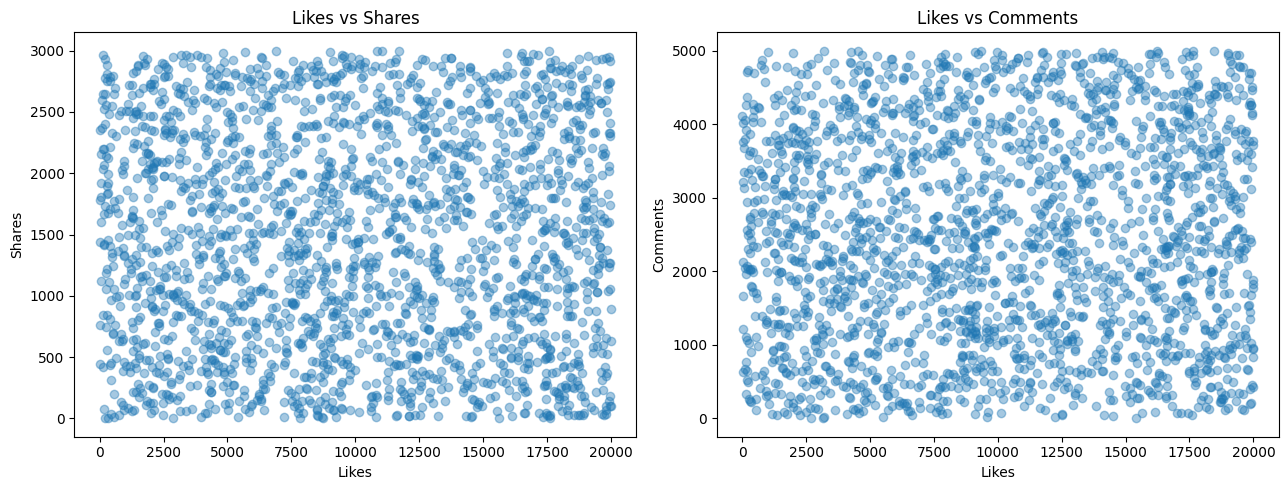

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["like_count"], df["share_count"], alpha=0.4)
axes[0].set_xlabel("Likes")
axes[0].set_ylabel("Shares")
axes[0].set_title("Likes vs Shares")

axes[1].scatter(df["like_count"], df["comment_count"], alpha=0.4)
axes[1].set_xlabel("Likes")
axes[1].set_ylabel("Comments")
axes[1].set_title("Likes vs Comments")

plt.tight_layout()
plt.show()

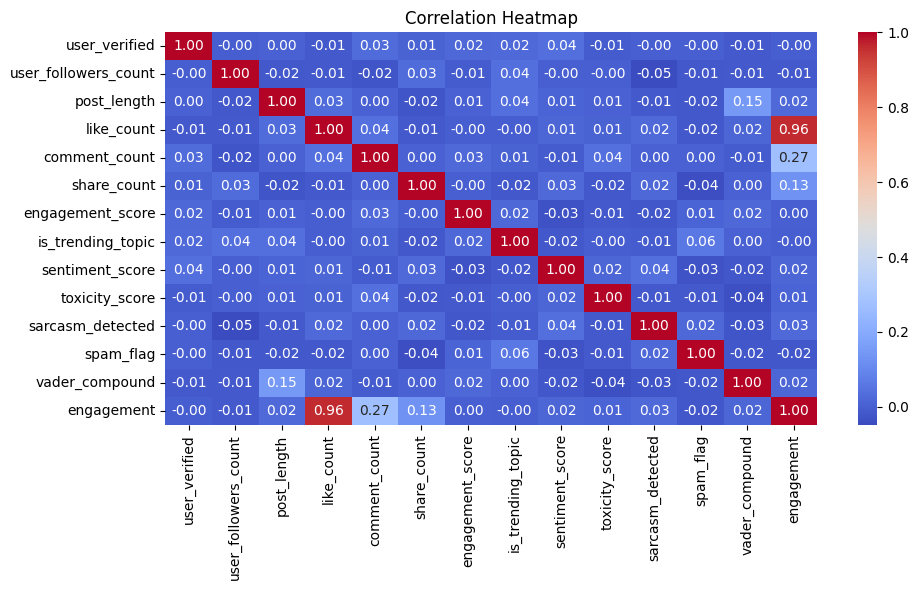

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

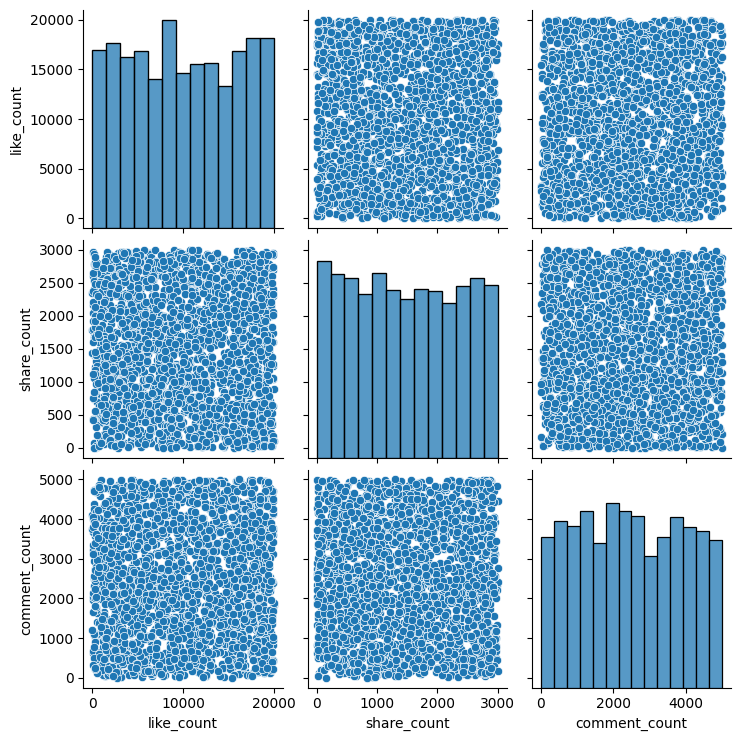

In [8]:
sns.pairplot(df[["like_count", "share_count", "comment_count"]])
plt.show()

## Top content and categorical breakdowns

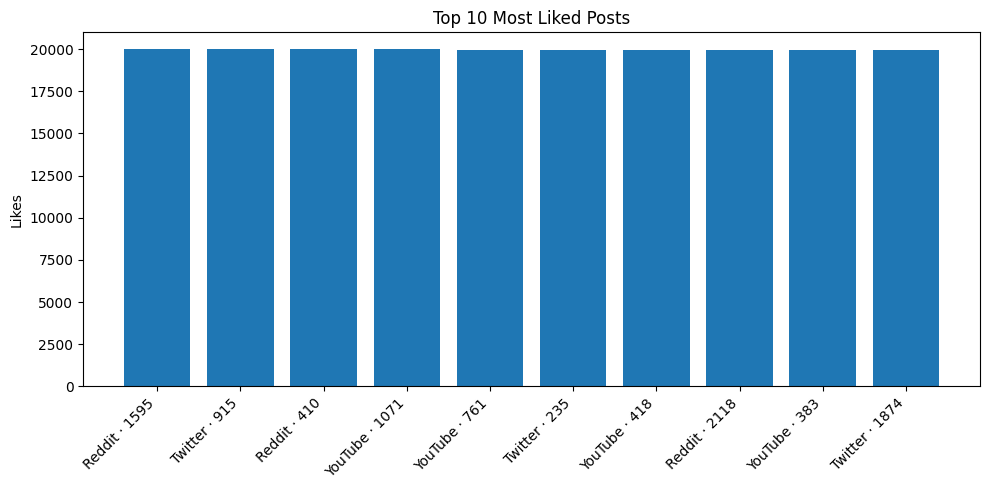

In [9]:
top_liked = df.sort_values("like_count", ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_liked["platform"] + " · " + top_liked.index.astype(str), top_liked["like_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Most Liked Posts")
plt.ylabel("Likes")
plt.tight_layout()
plt.show()

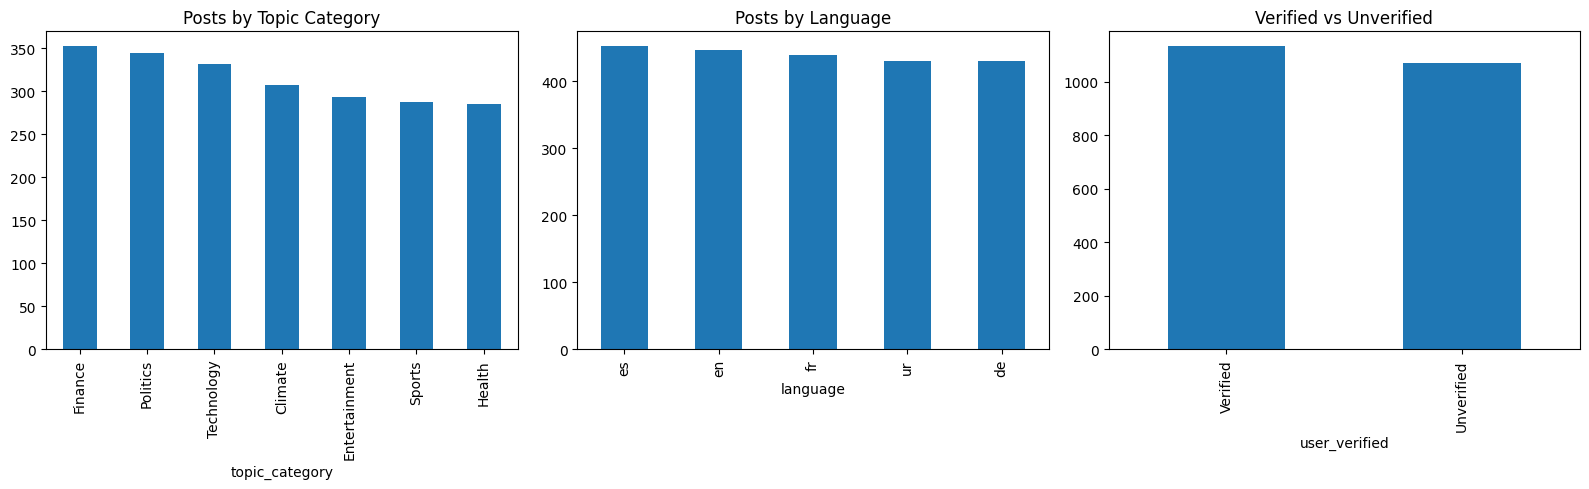

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df["topic_category"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Posts by Topic Category")

df["language"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Posts by Language")

df["user_verified"].map({True: "Verified", False: "Unverified"}).value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Verified vs Unverified")

plt.tight_layout()
plt.show()

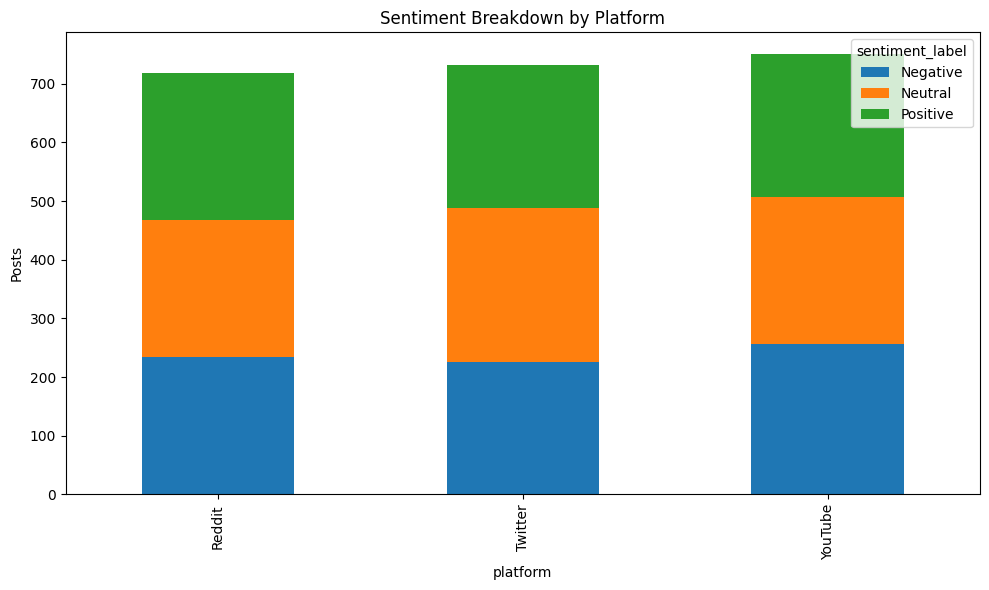

In [11]:
pd.crosstab(df["platform"], df["sentiment_label"]).plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sentiment Breakdown by Platform")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

## Word cloud of post text

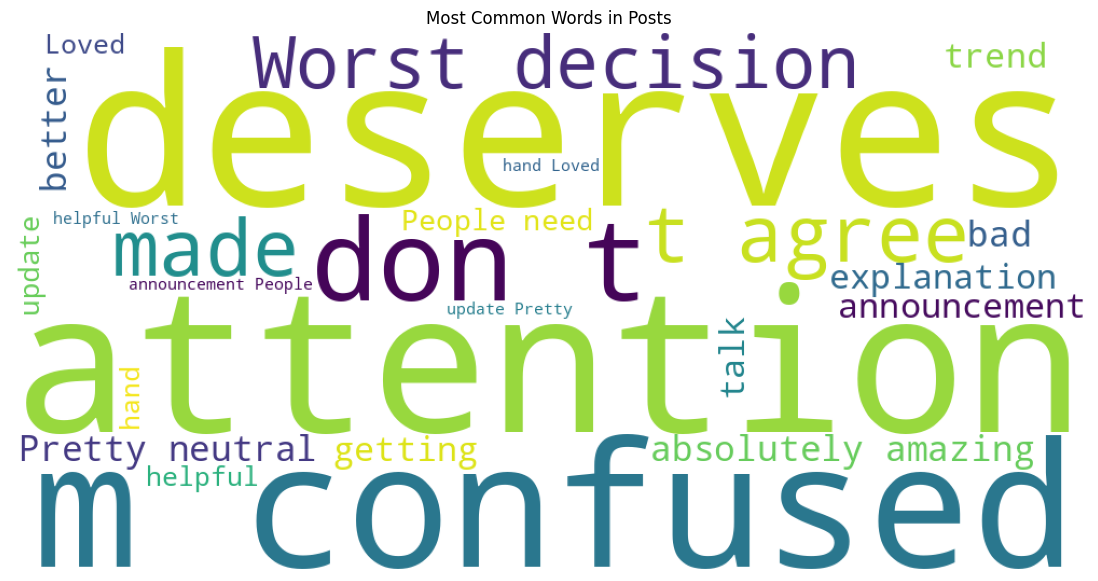

In [12]:
from wordcloud import WordCloud

text = " ".join(df["post_text"].astype(str))
wc = WordCloud(width=1000, height=500, background_color="white").generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wc)
plt.axis("off")
plt.title("Most Common Words in Posts")
plt.show()